In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
from transformers import GPT2Model,GPT2Tokenizer

# pretrained GPT-2 model and tokenizer
gpt2 = GPT2Model.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

/opt/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/anaconda3/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [5]:
# embeddings matrix
embeddings = gpt2.wte.weight.detach().numpy()

In [ ]:
# find the size parameters in .config
gpt2.config

In [7]:
# the properties we'll use later
print(f'Embedding dimensions: {gpt2.config.n_embd}')
print(f'Vocab size: {gpt2.config.vocab_size}')
print(f'Size of embeddings matrix: {embeddings.shape}')

Embedding dimensions: 768
Vocab size: 50257
Size of embeddings matrix: (50257, 768)


In [8]:
# unembeddings matrix as the transpose of the (real) embeddings
unembeddings = embeddings.T

# confirm that transposing matrix a copy
print('id of embeddings:  ',id(embeddings))
print('id of unembeddings:',id(unembeddings))

id of embeddings:   13334135696
id of unembeddings: 13334134928


In [9]:
# a random unembeddings matrix
unembeddingsRand = np.random.randn(gpt2.config.n_embd,gpt2.config.vocab_size)

print(f'         Size of embeddings matrix: {embeddings.shape}')
print(f'Size of random unembeddings matrix: {unembeddingsRand.shape}')
print(f'  Size of real unembeddings matrix: {unembeddings.shape}')

         Size of embeddings matrix: (50257, 768)
Size of random unembeddings matrix: (768, 50257)
  Size of real unembeddings matrix: (768, 50257)


In [10]:
# pick a word
seedword = ' California'

# its token index
seed_idx = tokenizer.encode(seedword)

# make sure it's one token
seed_idx

[3442]

In [ ]:
# find its embedding vector
embed_vector = embeddings[seed_idx,:]

# plot it!
plt.figure(figsize=(10,3))
plt.scatter(range(gpt2.config.n_embd),embed_vector.squeeze(),s=30,c=abs(embed_vector),cmap='RdPu')
plt.gca().set(xlabel='Embedding dimension',ylabel='Embedding weight',xlim=[-3,gpt2.config.n_embd+2],
              title=f'Embedding (GPT2) of "{tokenizer.decode(seed_idx)}"')
plt.show()

In [12]:
# project the embedding vector onto the unembedding matrix
dpRand = embed_vector @ unembeddingsRand

# next token is the maximum dot product (unscaled cosine similarity)!
nextTokenRand_idx = np.argmax(dpRand)
nextTokenRand = tokenizer.decode(nextTokenRand_idx)

# check the sizes
print('embed_vector  X  unembeddings  =  dotproducts')
print(f'  {embed_vector.shape}       {unembeddingsRand.shape}      {dpRand.shape}')

embed_vector  X  unembeddings  =  dotproducts
  (1, 768)       (768, 50257)      (1, 50257)


In [13]:
# repeat for the real unembeddings matrix
dpReal = embed_vector @ unembeddings
nextTokenReal_idx = np.argmax(dpReal)
nextTokenReal = tokenizer.decode(nextTokenReal_idx)

In [14]:
print('** Random unembeddings matrix:')
print(f'   "{tokenizer.decode(seed_idx)}" has largest dot product with token "{nextTokenRand}"\n')

print('** Real unembeddings matrix:')
print(f'   "{tokenizer.decode(seed_idx)}" has largest dot product with token "{nextTokenReal}"')

** Random unembeddings matrix:
   " California" has largest dot product with token "Eight"

** Real unembeddings matrix:
   " California" has largest dot product with token "California"


In [ ]:
# plot it!
_,axs = plt.subplots(1,2,figsize=(12,3))
axs[0].scatter(range(tokenizer.vocab_size),dpRand,s=30,c=abs(dpRand),cmap='RdPu',alpha=.4)
axs[0].axvline(nextTokenRand_idx,linestyle='--',color='k',alpha=1/3)
axs[0].plot(nextTokenRand_idx,dpRand[0,nextTokenRand_idx],'gv')
axs[0].set(xlabel='Unembedding dimension',ylabel='Dot product',xlim=[-11,tokenizer.vocab_size+10],
              title=f'(Random) dot products with "{tokenizer.decode(seed_idx)}"')

axs[1].scatter(range(tokenizer.vocab_size),dpReal,s=30,c=abs(dpReal),cmap='RdPu',alpha=.4)
axs[1].axvline(nextTokenReal_idx,linestyle='--',color='k',alpha=1/3)
axs[1].plot(nextTokenReal_idx,dpReal[0,nextTokenReal_idx],'gv')
axs[1].set(xlabel='Unembedding dimension',ylabel='Dot product',xlim=[-11,tokenizer.vocab_size+10],
              title=f'(Real) dot products with "{tokenizer.decode(seed_idx)}"')


plt.tight_layout()
plt.show()

In [16]:
top10 = np.argsort(dpReal[0])[::-1][:10]

for i in top10:
  print(f'Dot product {dpReal[0,i]:6.3f} for token "{tokenizer.decode(i)}"')

Dot product 10.136 for token "California"
Dot product  9.617 for token " California"
Dot product  8.816 for token " Californ"
Dot product  8.088 for token "Calif"
Dot product  7.718 for token " Calif"
Dot product  7.359 for token " Nevada"
Dot product  7.158 for token "Arizona"
Dot product  7.151 for token "Colorado"
Dot product  6.974 for token "Florida"
Dot product  6.912 for token "Oregon"


In [17]:
# sequence length
seq_len = 10

# initial seed
nextword = 'budget'

# initializing a list that will contain the text
text = nextword


# loop to create the sequence
for i in range(seq_len-1):

  # step 1: tokenize
  token = tokenizer.encode(nextword)

  # step 2: get embedding vector
  embed_vector = embeddings[token,:]

  # step 3: project onto unembedding matrix (dot products)
  dp = embed_vector @ unembeddings

  # step 4: find top10 projections
  top10 = np.argsort(dp[0])[::-1][:10]

  # step 5: randomly pick one for next token
  aRandomToken = np.random.choice(top10)
  nextword = tokenizer.decode(aRandomToken)

  # step 6: append the text
  text += nextword

# print the final result!
print('Our very philosophically meaningful text:\n',text)


Our very philosophically meaningful text:
 budget contrace contraceptives pregnancies pregnanciesimesterveyardchwitzocausthovah


In [18]:
# initialize
nextword = 'budget'
text = nextword

# loop
for i in range(seq_len-1):

  # step 1: tokenize
  token = tokenizer.encode(nextword)

  # step 2: get embedding vector
  embed_vector = embeddings[token,:]

  # step 3: project onto RANDOM unembedding matrix
  dp = embed_vector @ unembeddingsRand

  # step 4: find top10 projections
  top10 = np.argsort(dp[0])[::-1][:10]

  # step 5: randomly pick one for next token
  aRandomToken = np.random.choice(top10)
  nextword = tokenizer.decode(aRandomToken)

  # step 6: append the text
  text += nextword

print('Our randomly meanderingful text:\n',text)

Our randomly meanderingful text:
 budgetAZ dissentget towards investigatedffic senator 101 quant


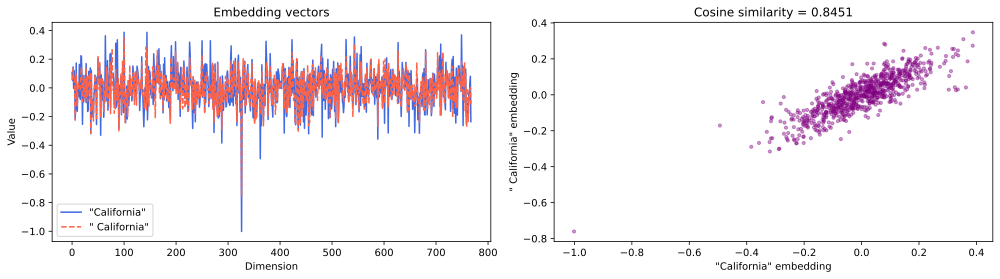

Token index of "California": 25284
Token index of " California": 3442
Cosine similarity: 0.8451


In [19]:
# 两个词
word1 = 'California'
word2 = ' California'  # 注意前面有空格

# 取出各自的 token index 和 embedding 向量
idx1 = tokenizer.encode(word1)[0]
idx2 = tokenizer.encode(word2)[0]
v1 = embeddings[idx1]
v2 = embeddings[idx2]

# 计算余弦相似度
cossim = np.sum(v1 * v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# 画图
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# 左图：两个词的 embedding 向量对比
axs[0].plot(v1, label=f'"{word1}"', color='royalblue')
axs[0].plot(v2, label=f'"{word2}"', color='tomato', linestyle='--')
axs[0].set(xlabel='Dimension', ylabel='Value', title='Embedding vectors')
axs[0].legend()

# 右图：v1 vs v2 散点图
axs[1].scatter(v1, v2, s=10, alpha=0.4, color='purple')
axs[1].set(xlabel=f'"{word1}" embedding', ylabel=f'"{word2}" embedding',
           title=f'Cosine similarity = {cossim:.4f}')

plt.tight_layout()
plt.show()

print(f'Token index of "{word1}": {idx1}')
print(f'Token index of "{word2}": {idx2}')
print(f'Cosine similarity: {cossim:.4f}')